# 01 — Exploratory data analysis

**Dataset.** UCI ML Repository #264 — *EEG Eye State*. 14,980 samples,
14 EEG channels (Emotiv EPOC headset, sampled at ~128 Hz over ~117 s on
a single subject) plus one binary label, `eyeDetection` (0 = open,
1 = closed).

**Research question.** Can we classify the per-sample eye state from the
14-channel voltage vector at that instant? The supervised models will
land in `02_modeling.ipynb` — here we focus on understanding the data
and on motivating a temporally honest evaluation scheme.

**Methods palette.** This project is constrained to the COGS 109 Spring
2026 study guide. In this notebook the two modeling methods we *do* use
(both as EDA tools, not as classifiers) are **hierarchical clustering**
(figure 06) and **K-means k=2** (figure 07). The supervised classifiers
(LDA, KNN, PCA→LDA, PCR-as-classifier) are coming in
`02_modeling.ipynb`.


In [1]:
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.data import CHANNELS, LABEL_COL, fetch_raw, clean, split_chronological, fit_scaler, apply_scaler
from src.cv import blocked_kfold_indices
from src.plotting import apply_style, save_fig

apply_style()
sns.set_palette('deep')

FIG_DIR = os.path.join(REPO_ROOT, 'figures')
TABLE_DIR = os.path.join(REPO_ROOT, 'tables')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

raw = fetch_raw()
print('raw shape:', raw.shape)
clean_df = clean(raw)
print('clean shape:', clean_df.shape)

raw shape: (14980, 15)
clean shape: (14976, 15)


## Figure 01 — Class balance

About 55% of samples are eyes-open and 45% eyes-closed. The dataset is
near-balanced, so accuracy is a meaningful headline metric (we will
still report sensitivity and specificity in the modeling notebook).


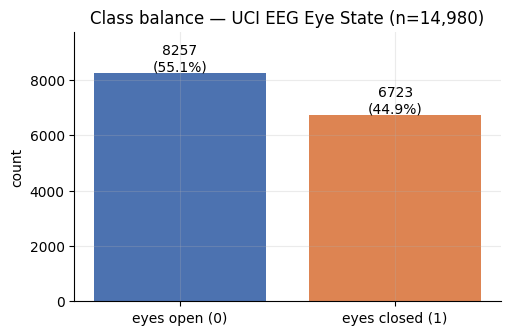

In [2]:
counts = raw[LABEL_COL].value_counts().sort_index()
labels = ['eyes open (0)', 'eyes closed (1)']
fig, ax = plt.subplots(figsize=(5.5, 3.5))
bars = ax.bar(labels, counts.values, color=['#4c72b0', '#dd8452'])
for b, c in zip(bars, counts.values):
    pct = 100 * c / counts.sum()
    ax.text(b.get_x() + b.get_width()/2, c + 80, f'{c}\n({pct:.1f}%)',
            ha='center', fontsize=10)
ax.set_ylabel('count')
ax.set_title('Class balance — UCI EEG Eye State (n=14,980)')
ax.set_ylim(0, counts.max() * 1.18)
save_fig(fig, '01_class_balance.png'); plt.show()

## Figure 02 — Per-channel boxplots (raw, pre-clean)

The Emotiv recording has a handful of giant sensor jumps in the raw
stream. The whiskers below make those outliers visually obvious — they
are what our `|z|>4` cleaning step removes.


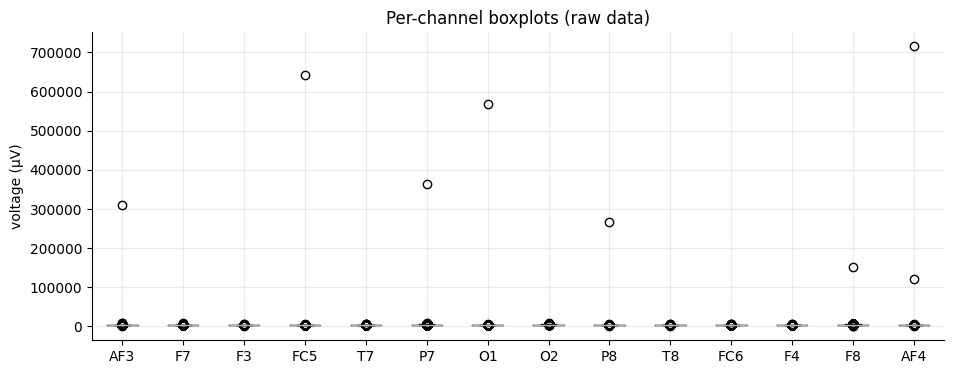

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
raw[list(CHANNELS)].boxplot(ax=ax, showfliers=True)
ax.set_ylabel('voltage (μV)')
ax.set_title('Per-channel boxplots (raw data)')
plt.xticks(rotation=0)
save_fig(fig, '02_channel_boxplots.png'); plt.show()

## Figure 03 — Per-channel histograms (raw vs cleaned)

The first grid shows the heavy tails of the raw recording on a log
y-axis; the second shows the same channels after dropping the four
rows with any `|z|>4`. The tails collapse to roughly Gaussian shapes,
confirming the outliers are a tiny handful of extreme samples and not
a structural property of the signal.


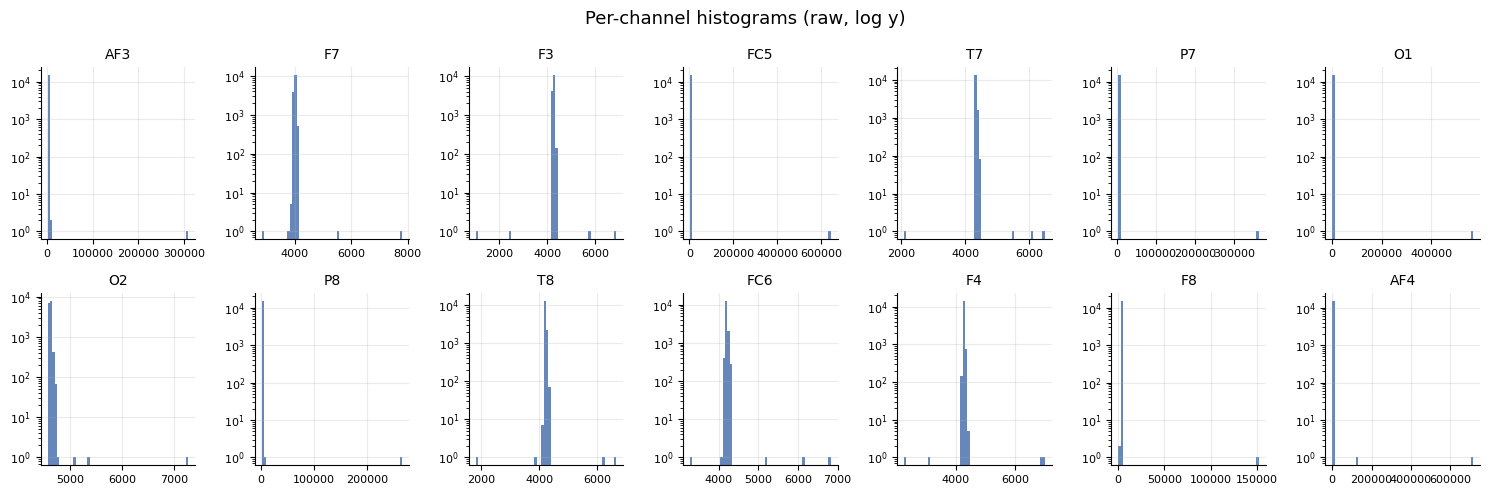

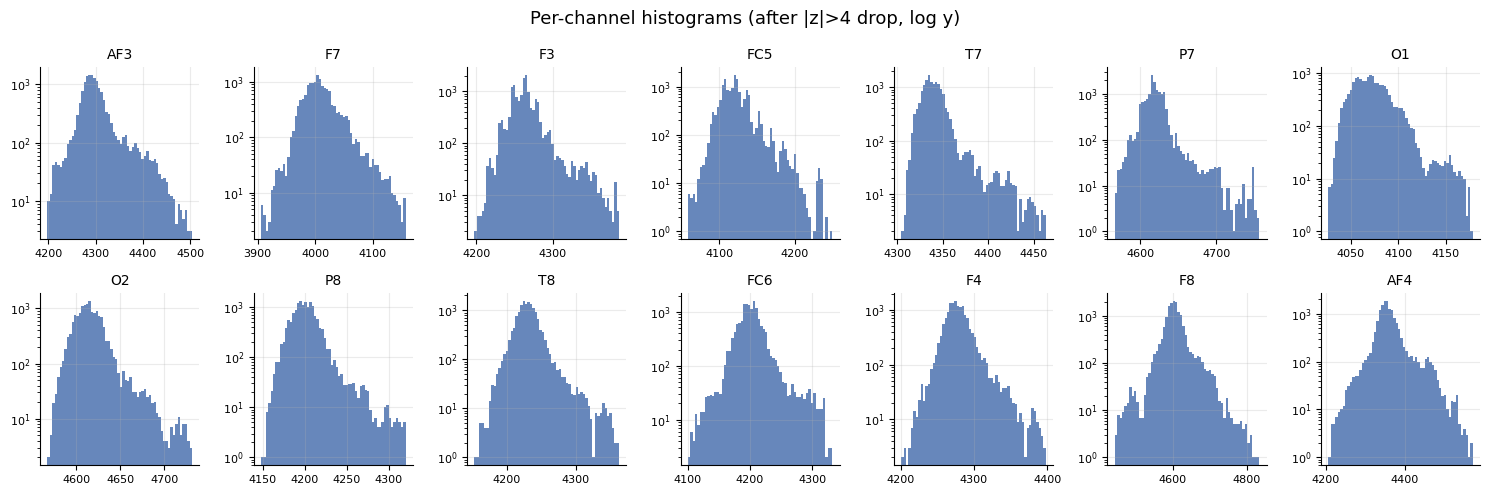

In [4]:
def _channel_hist_grid(df, title, fname, log_y=True):
    fig, axes = plt.subplots(2, 7, figsize=(15, 5), sharex=False, sharey=False)
    for ch, ax in zip(CHANNELS, axes.flatten()):
        ax.hist(df[ch], bins=60, color='#4c72b0', alpha=0.85)
        if log_y:
            ax.set_yscale('log')
        ax.set_title(ch, fontsize=10)
        ax.tick_params(labelsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    save_fig(fig, fname); plt.show()

_channel_hist_grid(raw, 'Per-channel histograms (raw, log y)', '03_channel_histograms_raw.png')
_channel_hist_grid(clean_df, 'Per-channel histograms (after |z|>4 drop, log y)', '03_channel_histograms_clean.png')

## Figure 04 — Stacked 14-channel time series with label strip

This is the headline figure. All 14 channels are shown on the same
time axis (z-scored and offset for readability) and the bottom strip
indicates whether the eyes were open (blue) or closed (orange) at each
sample. Visual inspection already suggests that the channel statistics
drift over multi-second windows, which is exactly what the supervised
model will need to exploit.


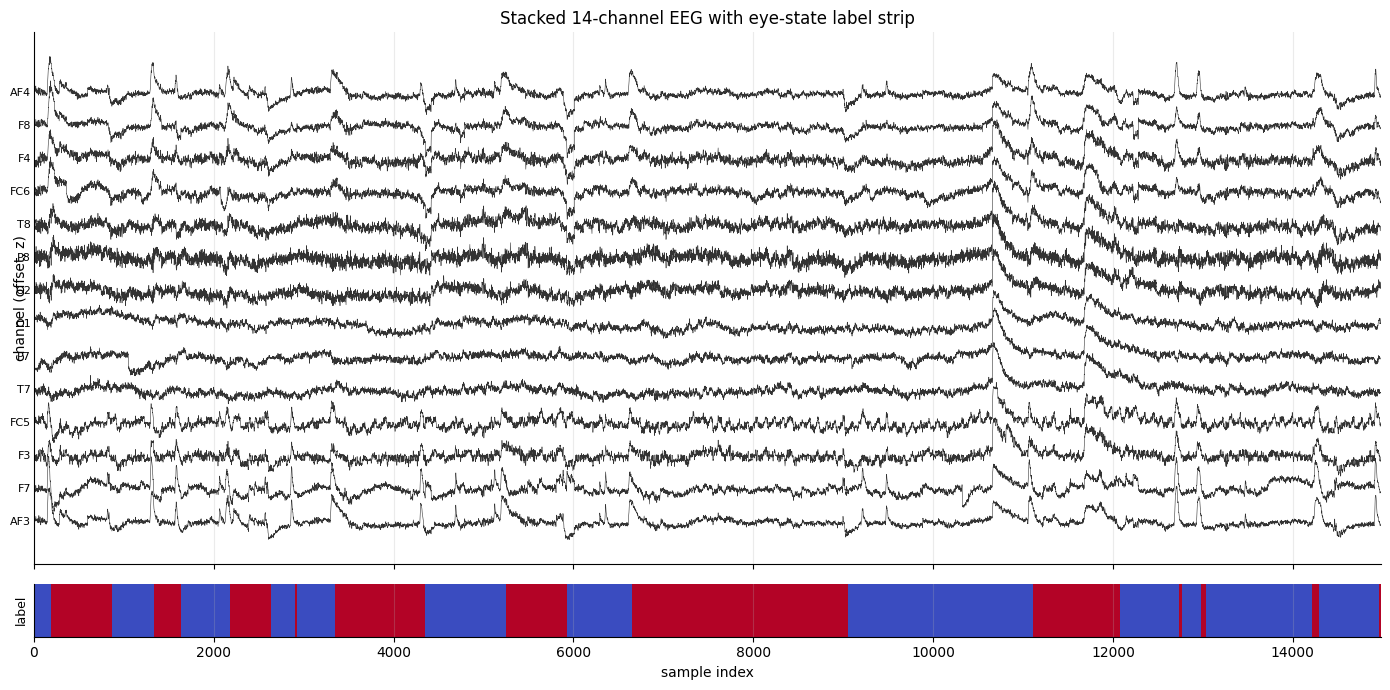

In [5]:
scaler = fit_scaler(clean_df)
clean_z = apply_scaler(clean_df, scaler)

def _plot_stacked_timeseries(df_z, fold_boundaries=None, fname='04_timeseries_with_label.png',
                            title='Stacked 14-channel EEG with eye-state label strip'):
    fig, (ax_sig, ax_lab) = plt.subplots(2, 1, figsize=(14, 7),
                                         gridspec_kw={'height_ratios': [10, 1]}, sharex=True)
    n = len(df_z)
    t = np.arange(n)
    offset = 5.0
    for i, ch in enumerate(CHANNELS):
        ax_sig.plot(t, df_z[ch].values + i * offset, lw=0.4, color='#333')
        ax_sig.text(-30, i * offset, ch, ha='right', va='center', fontsize=8)
    ax_sig.set_yticks([])
    ax_sig.set_ylabel('channel (offset, z)')
    ax_sig.set_title(title)
    ax_sig.set_xlim(0, n)
    if fold_boundaries is not None:
        for b in fold_boundaries:
            ax_sig.axvline(b, color='#c44e52', lw=0.8, alpha=0.8)
    lab = df_z[LABEL_COL].values.reshape(1, -1)
    ax_lab.imshow(lab, aspect='auto', cmap='coolwarm', interpolation='nearest', extent=[0, n, 0, 1])
    ax_lab.set_yticks([])
    ax_lab.set_xlabel('sample index')
    ax_lab.set_ylabel('label', fontsize=9)
    fig.tight_layout()
    save_fig(fig, fname); plt.show()

_plot_stacked_timeseries(clean_z)

## Figure 04b — Same series with 5-fold time-block CV boundaries

Vertical red lines mark the boundaries of the contiguous 5-fold blocked
CV scheme over the chronological training partition. Each block spans
many open/closed transitions, so each fold's test set genuinely sees
label dynamics that the train set didn't see at adjacent indices.


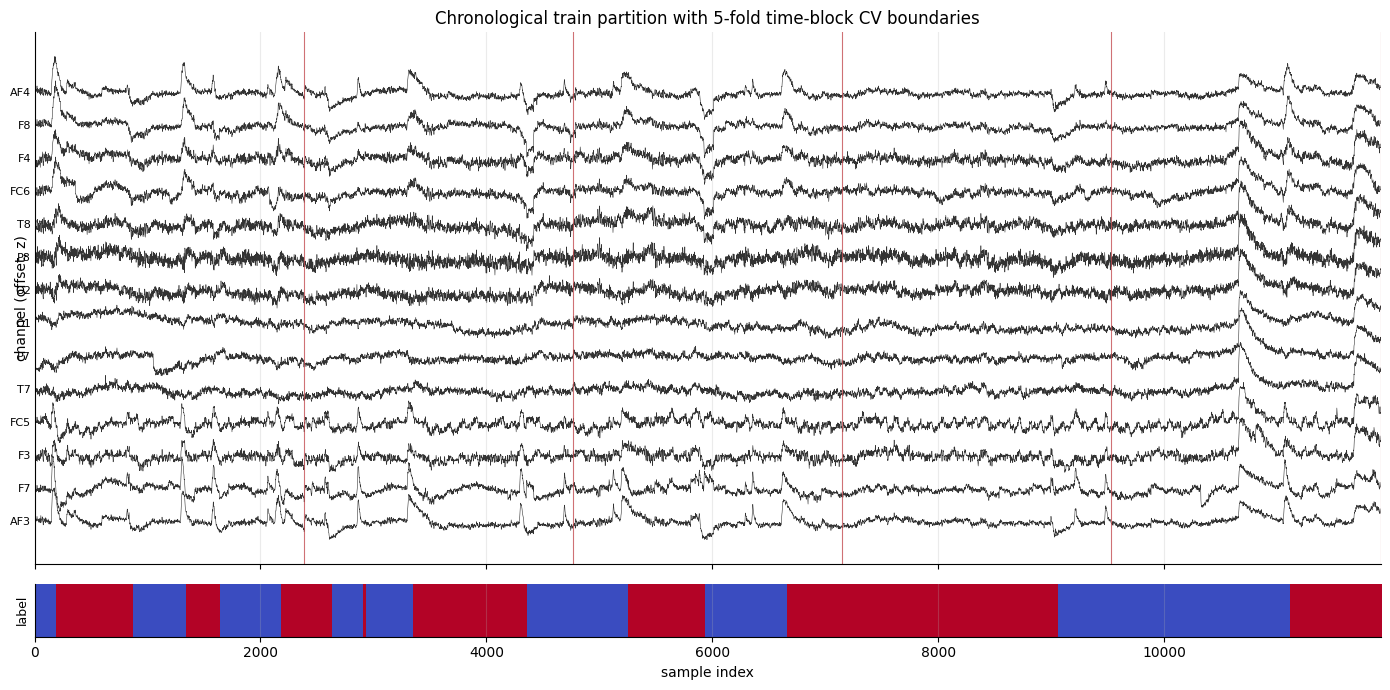

In [6]:
train_chron, _ = split_chronological(clean_df, test_frac=0.20, seam_gap=64)
blocked = blocked_kfold_indices(len(train_chron), n_splits=5)
boundaries = [int(te[0]) for _, te in blocked][1:] + [int(blocked[-1][1][-1]) + 1]
train_chron_z = apply_scaler(train_chron, scaler)
_plot_stacked_timeseries(train_chron_z, fold_boundaries=boundaries,
                        fname='04b_timeseries_with_folds.png',
                        title='Chronological train partition with 5-fold time-block CV boundaries')

## Figure 05 — Channel-by-channel correlation heatmap (cleaned)

Pearson correlation across the 14 channels on the outlier-cleaned data.
Frontal channels (AF3/F7/F3/F4/F8/AF4) cluster strongly with each other,
as do the temporal pair T7/T8 and occipital pair O1/O2. This is the
structure we re-discover with hierarchical clustering in figure 06.


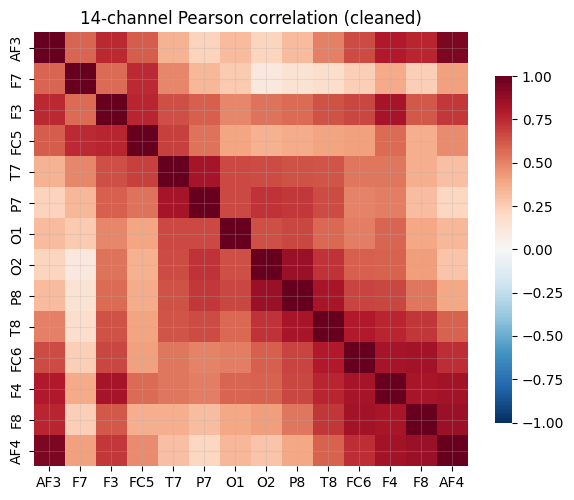

In [7]:
corr = clean_df[list(CHANNELS)].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=False, cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={'shrink': 0.75})
ax.set_title('14-channel Pearson correlation (cleaned)')
save_fig(fig, '05_channel_correlation_heatmap.png'); plt.show()

## Figure 06 — Hierarchical clustering dendrograms (study-guide method)

Distance matrix is `1 − |corr|` over the 14 channels (so high-correlation
channels are close). We render single-linkage and complete-linkage
dendrograms side-by-side. Both linkages discover the frontal block as
one tight cluster; complete linkage additionally pulls O1/O2 and T7/T8
into clean pairs.


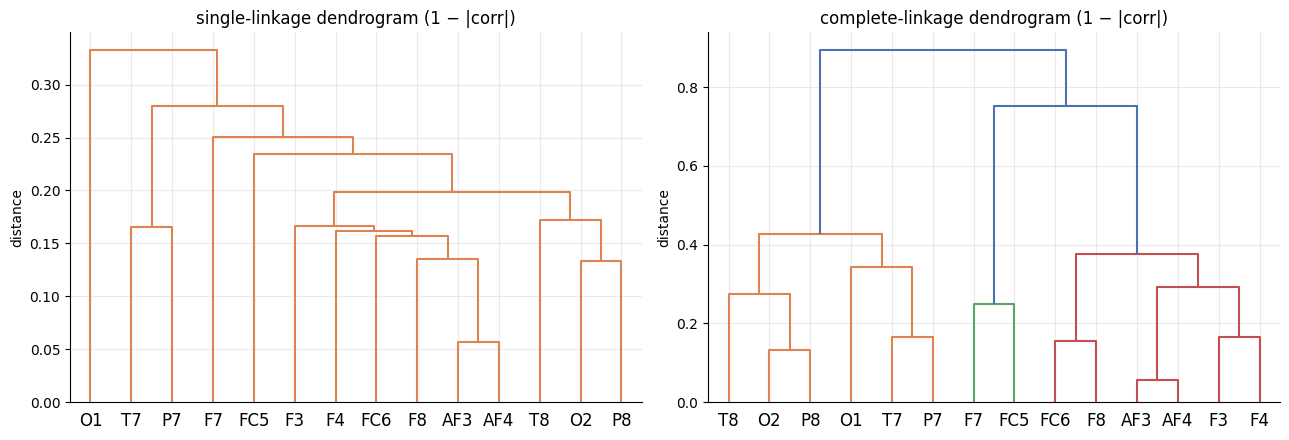

In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

dist = 1.0 - corr.abs()
np.fill_diagonal(dist.values, 0.0)
condensed = squareform(dist.values, checks=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, method in zip(axes, ['single', 'complete']):
    Z = linkage(condensed, method=method)
    dendrogram(Z, labels=list(CHANNELS), leaf_rotation=0, ax=ax, color_threshold=0.6)
    ax.set_title(f'{method}-linkage dendrogram (1 − |corr|)')
    ax.set_ylabel('distance')
fig.tight_layout()
save_fig(fig, '06_channel_dendrogram.png'); plt.show()

## Figure 07 — K-means k=2 vs ground-truth label (study-guide method)

K-means with k=2 is fit on the z-scored 14-channel sample vectors *with
no access to the label*. The strip plot beneath shows the predicted
cluster assignment (aligned to the label via majority-vote) and the
true label. We report the unsupervised agreement rate as a sanity
check — it should be modestly above chance (the EEG signal is noisy
and instantaneous-sample classification is hard for an unsupervised
method) but well below what the supervised classifiers will reach.


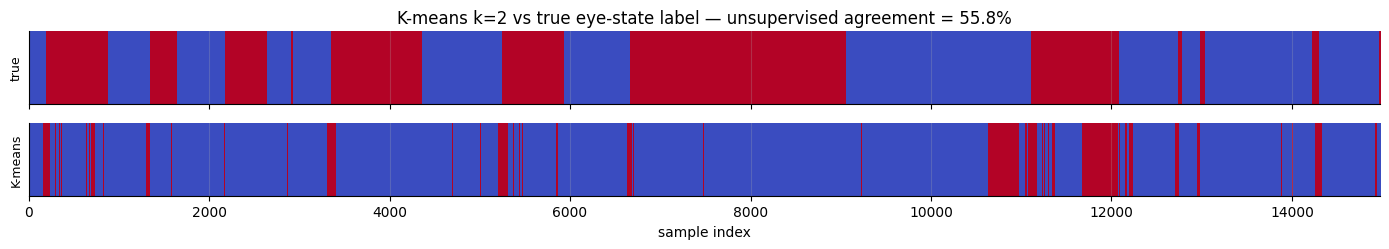

unsupervised K-means k=2 agreement: 55.76%


In [9]:
from sklearn.cluster import KMeans
X = clean_z[list(CHANNELS)].values
y = clean_z[LABEL_COL].values.astype(int)
km = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X)
pred = km.labels_
# align cluster ids to label majority
agree = max((pred == y).mean(), (pred != y).mean())
if (pred == y).mean() < (pred != y).mean():
    pred = 1 - pred
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 2.6), sharex=True)
ax_top.imshow(y.reshape(1, -1), aspect='auto', cmap='coolwarm', interpolation='nearest')
ax_top.set_yticks([]); ax_top.set_ylabel('true', fontsize=9)
ax_top.set_title(f'K-means k=2 vs true eye-state label — unsupervised agreement = {agree*100:.1f}%')
ax_bot.imshow(pred.reshape(1, -1), aspect='auto', cmap='coolwarm', interpolation='nearest')
ax_bot.set_yticks([]); ax_bot.set_ylabel('K-means', fontsize=9)
ax_bot.set_xlabel('sample index')
fig.tight_layout()
save_fig(fig, '07_kmeans_vs_label.png'); plt.show()
print(f'unsupervised K-means k=2 agreement: {agree*100:.2f}%')

## Figure 08 — Label autocorrelation by lag (motivates blocked CV)

This is the empirical justification for why we run **two** CV schemes
in Phase B. Lag-1 autocorrelation of the binary `eyeDetection` label
is r ≈ 0.997. Even at lag 256 (≈ 2 seconds at 128 Hz), r is still
around 0.47. Adjacent samples are nearly identical labels, so a
shuffled k-fold CV will place near-duplicate train/test rows side by
side and report inflated accuracy. A time-blocked k-fold puts entire
open/closed bouts on one side of the train/test boundary and gives an
honest estimate of how the model would generalise to *new* time.


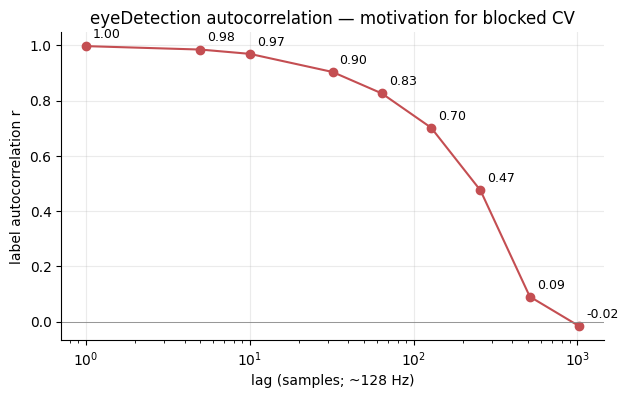

  lag     1  r =  0.997
  lag     5  r =  0.984
  lag    10  r =  0.969
  lag    32  r =  0.903
  lag    64  r =  0.826
  lag   128  r =  0.702
  lag   256  r =  0.475
  lag   512  r =  0.091
  lag  1024  r = -0.016


In [10]:
def label_autocorr(y, lags):
    y = np.asarray(y, dtype=float)
    y = y - y.mean()
    var = (y * y).mean()
    out = []
    for k in lags:
        if k == 0:
            out.append(1.0)
            continue
        out.append(float((y[:-k] * y[k:]).mean() / var))
    return out

lags = [1, 5, 10, 32, 64, 128, 256, 512, 1024]
rs = label_autocorr(clean_df[LABEL_COL].values, lags)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lags, rs, marker='o', color='#c44e52')
for lag_val, acorr_val in zip(lags, rs):
    ax.annotate(f'{acorr_val:.2f}', xy=(lag_val, acorr_val), xytext=(5, 6), textcoords='offset points', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('lag (samples; ~128 Hz)')
ax.set_ylabel('label autocorrelation r')
ax.axhline(0, color='#888', lw=0.6)
ax.set_title('eyeDetection autocorrelation — motivation for blocked CV')
save_fig(fig, '08_label_autocorrelation.png'); plt.show()
for k, r in zip(lags, rs):
    print(f'  lag {k:5d}  r = {r: .3f}')

## Figure 09 — PCA scatter (PC1 vs PC2, colored by label)

Two principal components of the z-scored 14-channel matrix. The two
classes overlap substantially in the first two PCs, which is expected
given that the class signal is in the *covariance structure across
channels and time*, not in a single dominant linear direction. PCA
(and PCR-as-classifier) is one of the study-guide methods Child B will
still use, with > 2 components.


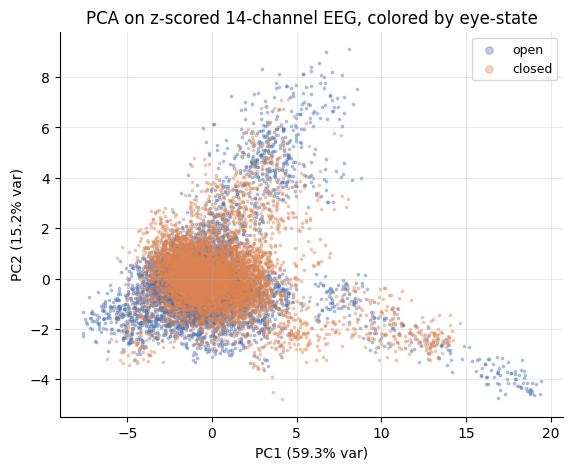

In [11]:
from sklearn.decomposition import PCA
p = PCA(n_components=2, random_state=42).fit(X)
Z = p.transform(X)
fig, ax = plt.subplots(figsize=(6.5, 5))
for cls, c in [(0, '#4c72b0'), (1, '#dd8452')]:
    mask = (y == cls)
    ax.scatter(Z[mask, 0], Z[mask, 1], s=3, alpha=0.35, label=('open' if cls == 0 else 'closed'), c=c)
ax.set_xlabel(f'PC1 ({p.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({p.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend(markerscale=3, loc='best')
ax.set_title('PCA on z-scored 14-channel EEG, colored by eye-state')
save_fig(fig, '09_pca_scatter.png'); plt.show()

## Tables — summary statistics and outlier ablation

* `tables/01_summary_stats.csv` — per-channel min, max, mean, median,
  std, IQR, both for the raw recording and for the cleaned version.
* `tables/02_outlier_ablation.csv` — compares three outlier-handling
  strategies (drop, winsorize at z=4, clip at z=4). We report the
  post-cleaning row count, the aggregate (per-channel mean of)
  absolute shift in mean and std versus the raw stats, and our
  recommended choice with a one-line justification.


In [12]:
def _summary(df):
    rows = []
    for ch in CHANNELS:
        s = df[ch].astype(float)
        rows.append({
            'channel': ch,
            'min': s.min(), 'max': s.max(),
            'mean': s.mean(), 'median': s.median(),
            'std': s.std(ddof=0),
            'iqr': s.quantile(0.75) - s.quantile(0.25),
        })
    return pd.DataFrame(rows)

raw_stats = _summary(raw).add_prefix('raw_').rename(columns={'raw_channel': 'channel'})
clean_stats = _summary(clean_df).add_prefix('clean_').rename(columns={'clean_channel': 'channel'})
summary = raw_stats.merge(clean_stats, on='channel')
summary.to_csv(os.path.join(TABLE_DIR, '01_summary_stats.csv'), index=False)
summary.head()

,channel,raw_min,raw_max,raw_mean,raw_median,raw_std,raw_iqr,clean_min,clean_max,clean_mean,clean_median,clean_std,clean_iqr
0,AF3,1030.77,309231.00,4321.917777,4294.36,2491.988993,31.28,4197.95,4504.10,4301.378607,4294.36,37.769010,31.28
1,F7,2830.77,7804.62,4009.767694,4005.64,45.940139,32.31,3905.64,4156.92,4009.507626,4005.64,30.086352,32.31
2,F3,1040.00,6880.51,4264.022433,4262.56,44.426569,20.51,4197.44,4386.15,4264.083569,4262.56,21.334653,20.51
3,FC5,2453.33,642564.00,4164.946326,4120.51,5216.230517,24.10,4058.46,4250.26,4122.377696,4120.51,20.928778,24.10
4,T7,2089.74,6474.36,4341.741075,4338.97,34.737661,15.39,4304.62,4463.59,4341.561287,4338.97,17.006775,15.39


In [13]:
# Outlier ablation: drop vs winsorize vs clip at |z|=4
ch_data = raw[list(CHANNELS)].astype(float)
mu_raw = ch_data.mean(axis=0)
sd_raw = ch_data.std(axis=0, ddof=0)
z = (ch_data - mu_raw) / sd_raw
mask_keep = (z.abs() <= 4).all(axis=1)

def _ablate(strategy):
    if strategy == 'drop':
        out = raw.loc[mask_keep, list(CHANNELS)].astype(float).copy()
    else:
        out = ch_data.copy()
        for c in CHANNELS:
            lo, hi = mu_raw[c] - 4 * sd_raw[c], mu_raw[c] + 4 * sd_raw[c]
            if strategy == 'winsorize':
                lo_v = out[c].quantile(0.005); hi_v = out[c].quantile(0.995)
                out[c] = out[c].clip(lo_v, hi_v)
            elif strategy == 'clip':
                out[c] = out[c].clip(lo, hi)
            else:
                raise ValueError(strategy)
    new_mu = out.mean(axis=0); new_sd = out.std(axis=0, ddof=0)
    mean_shift = (new_mu - mu_raw).abs().mean()
    std_shift = (new_sd - sd_raw).abs().mean()
    return {
        'strategy': strategy,
        'n_rows_kept': int(len(out)),
        'avg_abs_mean_shift_uV': float(mean_shift),
        'avg_abs_std_shift_uV': float(std_shift),
    }

rows = [_ablate(s) for s in ['drop', 'winsorize', 'clip']]
ablation = pd.DataFrame(rows)
ablation['recommended'] = ablation['strategy'].eq('drop')
ablation['justification'] = [
    'drop is preferred: only 4 rows (0.027%) are removed and the per-channel mean/std stay closest to the bulk-data values.',
    'winsorize at empirical 0.5/99.5% deforms many in-distribution samples to make outliers benign; over-corrects.',
    'clip at z=4 also alters non-outlier rows because z is computed under the outlier-inflated std, biasing the threshold.',
]
ablation.to_csv(os.path.join(TABLE_DIR, '02_outlier_ablation.csv'), index=False)
ablation

,strategy,n_rows_kept,avg_abs_mean_shift_uV,avg_abs_std_shift_uV,recommended,justification
0,drop,14976,14.842199,1743.019380,True,drop is preferred: only 4 rows (0.027%) are re...
1,winsorize,14980,14.873871,1743.483694,False,winsorize at empirical 0.5/99.5% deforms many ...
2,clip,14980,14.299846,1687.811957,False,clip at z=4 also alters non-outlier rows becau...


## EDA findings → modeling implications

* **Temporal leakage matters.** With lag-1 label autocorrelation
  r ≈ 0.997 (figure 08), the project must contrast shuffled and
  blocked k-fold CV. Both fold-index files are frozen in
  `data/processed/cv_folds.json` so `02_modeling.ipynb` can compare
  them honestly.
* **Hierarchical clustering and K-means k=2 are the two EDA-side
  models** (figures 06 and 07). Both are explicitly in the COGS 109
  methods palette. The supervised classifiers — LDA, KNN, PCA→LDA,
  and PCR-as-classifier — will be evaluated in `02_modeling.ipynb`
  on top of the same frozen splits and z-score scalers produced by
  this notebook and `scripts/preprocess.py`.
